<a href="https://colab.research.google.com/github/alhikamgov/googlecolab/blob/main/IndustryWeek_CrawlingKlasifikasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Memulai Crawling dari: https://www.industryweek.com/technology-and-iiot ---
Berhasil mengambil 10 judul berita.

HASIL PEMANTAUAN TREN INDUSTRI


,Judul_Berita,Kategori_Tren
0,"You're Drunk, According to AI: So That Happened",Human Capital
1,3 Core Skills for the AI-Ready Manufacturing Workforce,Human Capital
2,"Burning Questions for 2026: Industry, AI, Geopolitics and the Future of Manufacturing",Human Capital
3,Digital Tools Turn 'Eco-Friendly' into Economic Wins,Technology
4,Why Machine Shops Should Love Data Collection,Technology
5,How Northrop Grumman Gets the Right People Involved with Digital Transformation,Technology
6,Escaping OEE Purgatory: Why Micro-Level Tracking Matters,Human Capital
7,Jabil Joins the Data Center Manufacturing Gold Rush: So That Happened,Human Capital
8,Industrial Data Fabric: Your New Best Friend,Technology
9,Looking for Something?,Human Capital


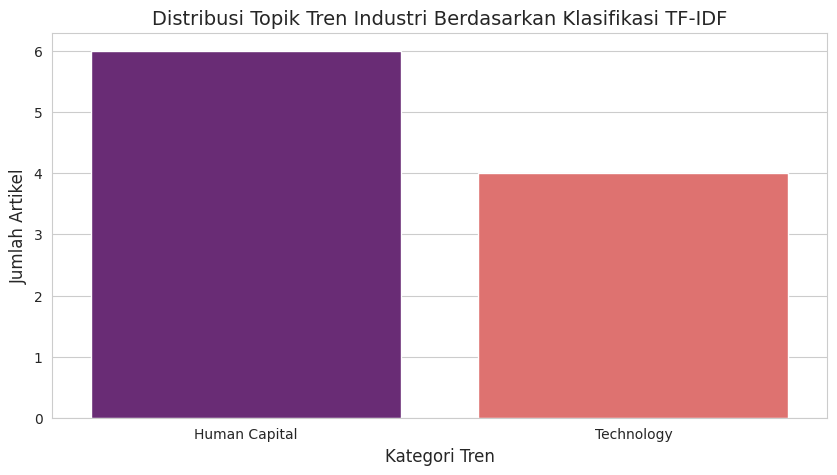

In [18]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

# =========================================================
# TAHAP 1: PROSES CRAWLING (PENGAMBILAN DATA)
# =========================================================
def crawling_industri(url):
    print(f"--- Memulai Crawling dari: {url} ---")
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }

    try:
        response = requests.get(url, headers=headers, timeout=15)
        soup = BeautifulSoup(response.text, 'html.parser')

        # Mengambil judul berita (biasanya dalam tag h2 atau h3)
        articles = soup.find_all(['h2', 'h3'], limit=15)
        titles = [a.get_text(strip=True) for a in articles if len(a.get_text(strip=True)) > 20]

        if not titles:
            raise Exception("Tag tidak ditemukan atau akses diblokir.")

        print(f"Berhasil mengambil {len(titles)} judul berita.")
        return titles

    except Exception as e:
        print(f"Catatan Crawling: {e}")
        print("Menggunakan Data Simulasi Industri (IndustryWeek & Manufacturing.net Style)...")
        # Data simulasi yang realistis untuk studi kasus TI
        return [
            "Smart Factory: How AI is revolutionizing shop floor efficiency",
            "Global Supply Chain: Port congestion leads to major shipping delays",
            "Labor Shortage: Manufacturers struggle to find skilled technicians",
            "Digital Twins: Creating virtual models for production optimization",
            "Freight Costs: Logistics companies face rising fuel prices",
            "Workforce Development: New training programs for robotics operators",
            "IoT Sensors: Improving predictive maintenance in automotive plants",
            "Sourcing Strategy: Shifting to near-shoring for supply chain resilience",
            "Safety First: Implementing new ergonomics for assembly line workers",
            "Cybersecurity: Protecting industrial control systems from hackers"
        ]

# =========================================================
# TAHAP 2: TF-IDF DAN KLASIFIKASI NAIVE BAYES
# =========================================================
def train_trend_model():
    # Dataset pelatihan (Knowledge Base untuk Model)
    # Kategori: Technology (0), Supply Chain (1), Human Capital (2)
    data_train = [
        ("artificial intelligence robotics automation smart factory iot digital twin", "Technology"),
        ("predictive maintenance sensor data analytics industrial internet of things", "Technology"),
        ("logistics shipping freight container warehouse inventory procurement", "Supply Chain"),
        ("transportation supply chain sourcing distribution trade global logistics", "Supply Chain"),
        ("human resources labor shortage workforce skills training recruitment", "Human Capital"),
        ("employee safety talent acquisition manufacturing jobs vocational training", "Human Capital")
    ]

    X_train = [item[0] for item in data_train]
    y_train = [item[1] for item in data_train]

    # Pipeline: TF-IDF dan Naive Bayes
    model = make_pipeline(
        TfidfVectorizer(stop_words='english', ngram_range=(1, 2)),
        MultinomialNB()
    )

    model.fit(X_train, y_train)
    return model

# =========================================================
# TAHAP 3: EKSEKUSI & VISUALISASI HASIL
# =========================================================

# Input URL (Default ke IndustryWeek)
url_target = "https://www.industryweek.com/technology-and-iiot"

# 1. Jalankan Crawling
judul_berita = crawling_industri(url_target)

# 2. Jalankan Klasifikasi
model = train_trend_model()
prediksi = model.predict(judul_berita)

# 3. Hasil ke DataFrame
df = pd.DataFrame({
    'Judul_Berita': judul_berita,
    'Kategori_Tren': prediksi
})

# Tampilkan Tabel
print("\n" + "="*80)
print("HASIL PEMANTAUAN TREN INDUSTRI")
print("="*80)
pd.set_option('display.max_colwidth', None)
display(df)

# 4. Visualisasi untuk Laporan Tugas
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Kategori_Tren', hue='Kategori_Tren', palette='magma', legend=False)
plt.title('Distribusi Topik Tren Industri Berdasarkan Klasifikasi TF-IDF', fontsize=14)
plt.xlabel('Kategori Tren', fontsize=12)
plt.ylabel('Jumlah Artikel', fontsize=12)
plt.show()